# SkyAware Flight Delay Prediction — Notebook 1: Exploratory Data Analysis

**AAI-540 MLOps | Group 4**

This notebook performs EDA on the BTS Airline On-Time Statistics dataset (2010–2025).
We derive the multi-class target variable and explore delay patterns by carrier, airport, season, and year.

**Target classes:**
- `0` = on-time (delay rate < 15%)
- `1` = minor risk (15–25%)
- `2` = major risk (25–40%)
- `3` = high risk (> 40% or cancellation rate > 5%)

## 1. Setup & Imports

In [1]:
!pip install "protobuf<5.0" --force-reinstall
!pip install sagemaker==2.224.4

  Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl (295 kB)


  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1


    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.73.1 requires protobuf<7.0.0,>=6.30.0, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.42.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.


  Using cached sagemaker-2.224.4-py3-none-any.whl.metadata (15 kB)
  Using cached attrs-23.2.0-py3-none-any.whl.metadata (9.5 kB)


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [sagemaker]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [sagemaker]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [sagemaker]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [sagemaker]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [sagemaker]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sagemaker-studio-analytics-extension 0.3.0 requires sparkmagic==0.22.0, but you have sparkmagic 0.21.0 which is incompatible.
sparkmagic 0.21.0 requires pandas<2.0.0,>=0.17.1, but you have pandas 2.3.3 which is incompatible.


In [2]:
%matplotlib inline
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import sagemaker
from sagemaker import get_execution_role

# AWS config
region = boto3.Session().region_name
role = get_execution_role()
account_id = boto3.client('sts').get_caller_identity()['Account']

# S3 buckets
RAW_BUCKET = 'skyaware-raw-data'
PROCESSED_BUCKET = 'skyaware-processed-data'

# Local dataset path (relative to notebook)
DATA_PATH = './Dataset/Airline_Delay_Cause.csv'

print(f'Region: {region}')
print(f'Account: {account_id}')
print(f'Role: {role[:60]}...')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


Region: us-east-1
Account: 706029888011
Role: arn:aws:iam::706029888011:role/LabRole...


## 2. Load Dataset

In [5]:
df = pd.read_csv(DATA_PATH)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Year range: {df["year"].min()} - {df["year"].max()}')
print(f'Carriers: {df["carrier"].nunique()}')
print(f'Airports: {df["airport"].nunique()}')
df.head()

Shape: (398233, 21)
Columns: ['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
Year range: 2003 - 2025
Carriers: 38
Airports: 425


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.0,...,0.0,2.66,2.0,0.0,409.0,236.0,0.0,70.0,0.0,103.0
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.0,...,0.0,0.00,0.0,0.0,1075.0,0.0,1075.0,0.0,0.0,0.0
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.0,...,0.0,0.00,1.0,0.0,446.0,336.0,0.0,110.0,0.0,0.0


In [6]:
s3_client = boto3.client('s3', region_name=region)

def create_bucket_if_missing(bucket_name):
    try:
        s3_client.head_bucket(Bucket=bucket_name)
        print(f'Bucket exists: s3://{bucket_name}')
    except Exception as e:
        error_code = e.response['Error']['Code'] if hasattr(e, 'response') else ''
        if error_code in ('404', 'NoSuchBucket'):
            try:
                if region == 'us-east-1':
                    s3_client.create_bucket(Bucket=bucket_name)
                else:
                    s3_client.create_bucket(
                        Bucket=bucket_name,
                        CreateBucketConfiguration={'LocationConstraint': region}
                    )
                print(f'Created bucket: s3://{bucket_name}')
            except Exception as create_err:
                print(f'Could not create {bucket_name}: {create_err}')
        else:
            print(f'Bucket check error for {bucket_name}: {e}')

for bucket in [RAW_BUCKET, PROCESSED_BUCKET]:
    create_bucket_if_missing(bucket)

Created bucket: s3://skyaware-raw-data


Created bucket: s3://skyaware-processed-data


In [7]:
# Upload raw data to S3
s3_client = boto3.client('s3', region_name=region)

try:
    s3_client.upload_file(DATA_PATH, RAW_BUCKET, 'raw/Airline_Delay_Cause.csv')
    print(f'Uploaded to s3://{RAW_BUCKET}/raw/Airline_Delay_Cause.csv')
except Exception as e:
    print(f'S3 upload note: {e}')
    print('Continuing with local file.')

Uploaded to s3://skyaware-raw-data/raw/Airline_Delay_Cause.csv


## 3. Data Quality Check

In [8]:
print('=== NULL COUNTS ===')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

print(f'\n=== DUPLICATES ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\n=== DATA TYPES ===')
print(df.dtypes)

print('\n=== DESCRIPTIVE STATS ===')
df[['arr_flights', 'arr_del15', 'arr_cancelled', 'arr_diverted']].describe()

=== NULL COUNTS ===
arr_flights            657
arr_del15              950
carrier_ct             657
weather_ct             657
nas_ct                 657
security_ct            657
late_aircraft_ct       657
arr_cancelled          657
arr_diverted           657
arr_delay              657
carrier_delay          657
weather_delay          657
nas_delay              657
security_delay         657
late_aircraft_delay    657
dtype: int64

=== DUPLICATES ===


Duplicate rows: 0

=== DATA TYPES ===
year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object

=== DESCRIPTIVE STATS ===


,arr_flights,arr_del15,arr_cancelled,arr_diverted
count,397576.000000,397283.000000,397576.000000,397576.000000
mean,361.663536,69.593947,6.789323,0.834168
std,993.947394,193.608821,35.086108,3.792889
min,1.000000,0.000000,0.000000,0.000000
25%,56.000000,8.000000,0.000000,0.000000
50%,113.000000,21.000000,1.000000,0.000000
75%,255.000000,52.000000,4.000000,1.000000
max,21977.000000,6377.000000,4951.000000,256.000000


In [9]:
# Filter to 2010+ and remove rows with zero flights
df = df[df['year'] >= 2010].copy()
df = df[df['arr_flights'] > 0].copy()

# Fill numeric nulls with 0 (missing delay counts = no delays)
delay_cols = ['arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct',
              'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
              'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
              'security_delay', 'late_aircraft_delay']
df[delay_cols] = df[delay_cols].fillna(0)

print(f'Records after filtering: {len(df):,}')
print(f'Year range: {df["year"].min()} - {df["year"].max()}')

Records after filtering: 281,032
Year range: 2010 - 2025


## 4. Target Variable Derivation

In [10]:
# Derive delay rate and cancellation rate
df['delay_rate'] = df['arr_del15'] / df['arr_flights']
df['cancel_rate'] = df['arr_cancelled'] / df['arr_flights']

# Multi-class target variable
def assign_risk_label(row):
    if row['cancel_rate'] > 0.05 or row['delay_rate'] > 0.40:
        return 3  # high risk
    elif row['delay_rate'] > 0.25:
        return 2  # major risk
    elif row['delay_rate'] > 0.15:
        return 1  # minor risk
    else:
        return 0  # on-time

df['delay_risk_label'] = df.apply(assign_risk_label, axis=1)

label_names = {0: 'on-time', 1: 'minor-risk', 2: 'major-risk', 3: 'high-risk'}
df['risk_label_name'] = df['delay_risk_label'].map(label_names)

print('=== CLASS DISTRIBUTION ===')
class_counts = df['delay_risk_label'].value_counts().sort_index()
for label, count in class_counts.items():
    pct = count / len(df) * 100
    print(f'  Class {label} ({label_names[label]}): {count:,} ({pct:.1f}%)')

=== CLASS DISTRIBUTION ===
  Class 0 (on-time): 102,652 (36.5%)
  Class 1 (minor-risk): 92,556 (32.9%)
  Class 2 (major-risk): 45,005 (16.0%)
  Class 3 (high-risk): 40,819 (14.5%)


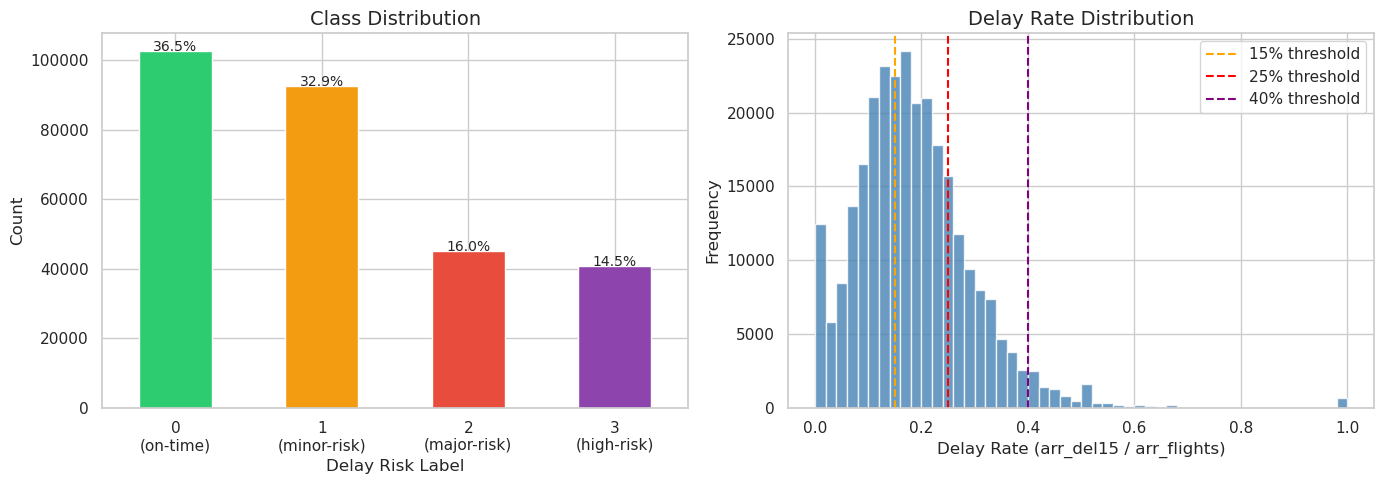

Imbalance ratio (high-risk : on-time): 0.398


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar chart
class_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'])
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xlabel('Delay Risk Label')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels([f'{i}\n({label_names[i]})' for i in range(4)], rotation=0)
for bar, count in zip(axes[0].patches, class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{count/len(df)*100:.1f}%', ha='center', fontsize=10)

# Delay rate distribution
axes[1].hist(df['delay_rate'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
for thresh, color, label in [(0.15, 'orange', '15%'), (0.25, 'red', '25%'), (0.40, 'purple', '40%')]:
    axes[1].axvline(thresh, color=color, linestyle='--', label=f'{label} threshold')
axes[1].set_title('Delay Rate Distribution', fontsize=14)
axes[1].set_xlabel('Delay Rate (arr_del15 / arr_flights)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Imbalance ratio (high-risk : on-time):', round(class_counts[3]/class_counts[0], 3))

## 5. Temporal Analysis (2010–2025)

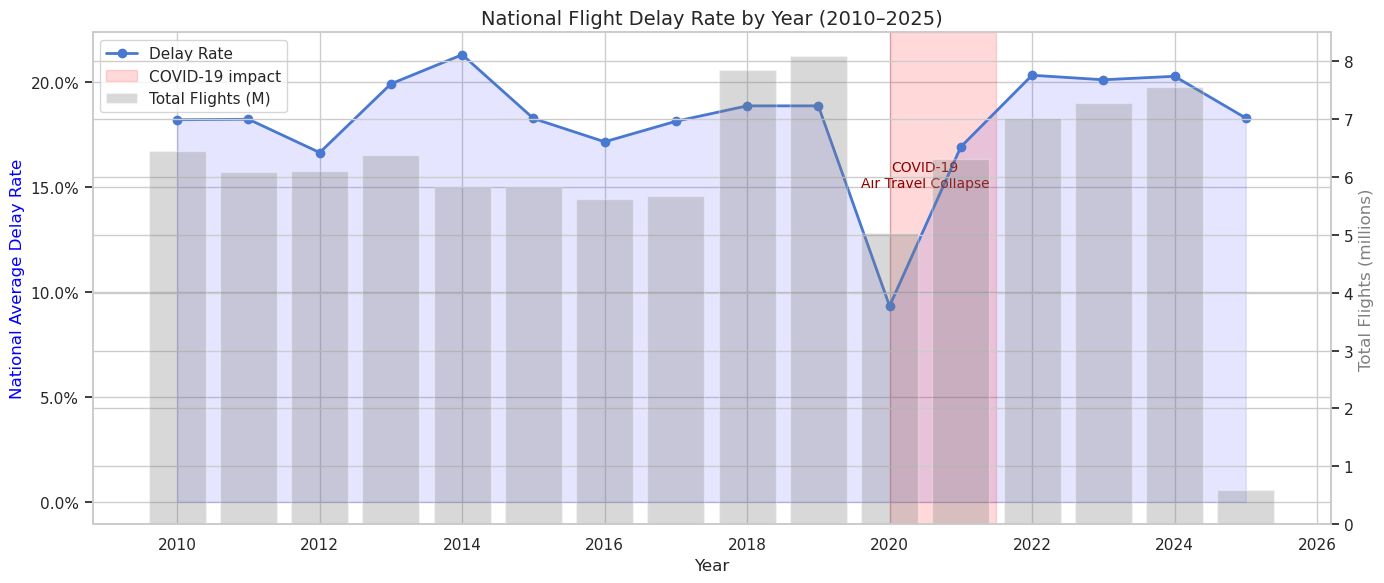


Yearly summary:
 year  avg_delay_rate  avg_cancel_rate  total_flights
 2010        0.182149         0.017559      6450117.0
 2011        0.182386         0.019059      6085281.0
 2012        0.166508         0.012935      6096762.0
 2013        0.199275         0.015074      6369482.0
 2014        0.213156         0.021819      5819811.0
 2015        0.182750         0.015446      5819079.0
 2016        0.171644         0.011724      5617658.0
 2017        0.181417         0.014572      5674621.0
 2018        0.188771         0.017136      7848697.0
 2019        0.188768         0.018986      8091684.0
 2020        0.093373         0.059942      5022397.0
 2021        0.169214         0.017589      6311871.0
 2022        0.203365         0.027096      7013508.0
 2023        0.201208         0.012900      7278739.0
 2024        0.202874         0.013636      7546968.0
 2025        0.182976         0.031285       599013.0


In [12]:
yearly = df.groupby('year').agg(
    total_flights=('arr_flights', 'sum'),
    total_delayed=('arr_del15', 'sum'),
    total_cancelled=('arr_cancelled', 'sum')
).reset_index()
yearly['avg_delay_rate'] = yearly['total_delayed'] / yearly['total_flights']
yearly['avg_cancel_rate'] = yearly['total_cancelled'] / yearly['total_flights']

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(yearly['year'], yearly['avg_delay_rate'], 'b-o', linewidth=2, label='Delay Rate')
ax1.fill_between(yearly['year'], yearly['avg_delay_rate'], alpha=0.1, color='blue')
ax2.bar(yearly['year'], yearly['total_flights']/1e6, alpha=0.3, color='gray', label='Total Flights (M)')

# Annotate COVID-19
ax1.axvspan(2020, 2021.5, alpha=0.15, color='red', label='COVID-19 impact')
ax1.annotate('COVID-19\nAir Travel Collapse', xy=(2020.5, 0.15), fontsize=10,
             color='darkred', ha='center')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('National Average Delay Rate', color='blue', fontsize=12)
ax2.set_ylabel('Total Flights (millions)', color='gray', fontsize=12)
ax1.set_title('National Flight Delay Rate by Year (2010–2025)', fontsize=14)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('temporal_delay_rate.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nYearly summary:')
print(yearly[['year', 'avg_delay_rate', 'avg_cancel_rate', 'total_flights']].to_string(index=False))

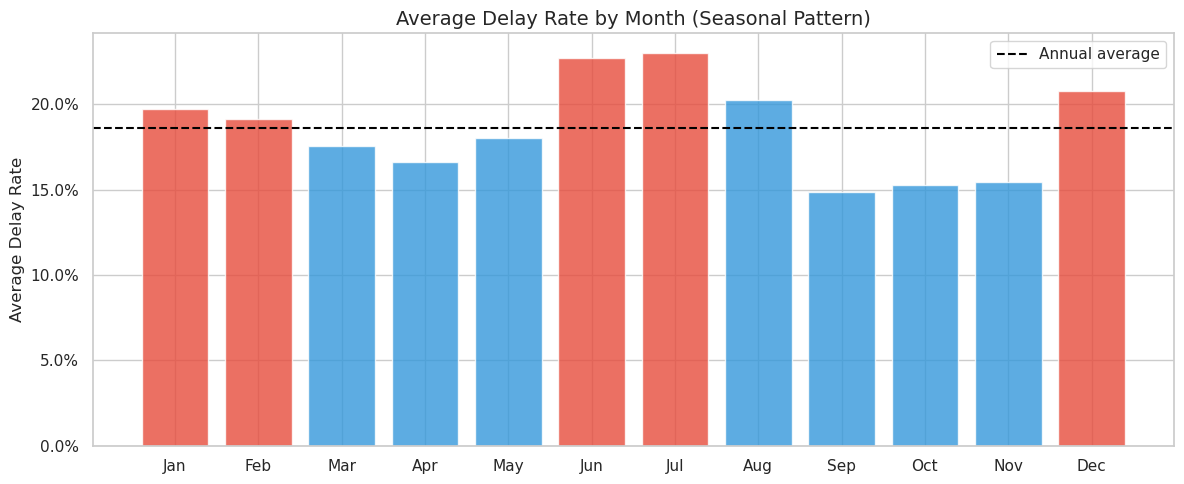

Peak delay month: Jul (month 7)
Lowest delay month: Sep (month 9)


In [13]:
# Seasonal pattern (monthly)
monthly = df.groupby('month').agg(
    avg_delay_rate=('delay_rate', 'mean'),
    avg_cancel_rate=('cancel_rate', 'mean')
).reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1,13), monthly['avg_delay_rate'], color=[
    '#e74c3c' if m in [12,1,2,6,7] else '#3498db' for m in range(1,13)
], alpha=0.8)
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names)
ax.set_title('Average Delay Rate by Month (Seasonal Pattern)', fontsize=14)
ax.set_ylabel('Average Delay Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.axhline(monthly['avg_delay_rate'].mean(), color='black', linestyle='--', label='Annual average')
ax.legend()
plt.tight_layout()
plt.savefig('seasonal_delay_rate.png', dpi=100, bbox_inches='tight')
plt.show()

peak_month = monthly.loc[monthly['avg_delay_rate'].idxmax(), 'month']
low_month = monthly.loc[monthly['avg_delay_rate'].idxmin(), 'month']
print(f'Peak delay month: {month_names[peak_month-1]} (month {peak_month})')
print(f'Lowest delay month: {month_names[low_month-1]} (month {low_month})')

## 6. Carrier Analysis

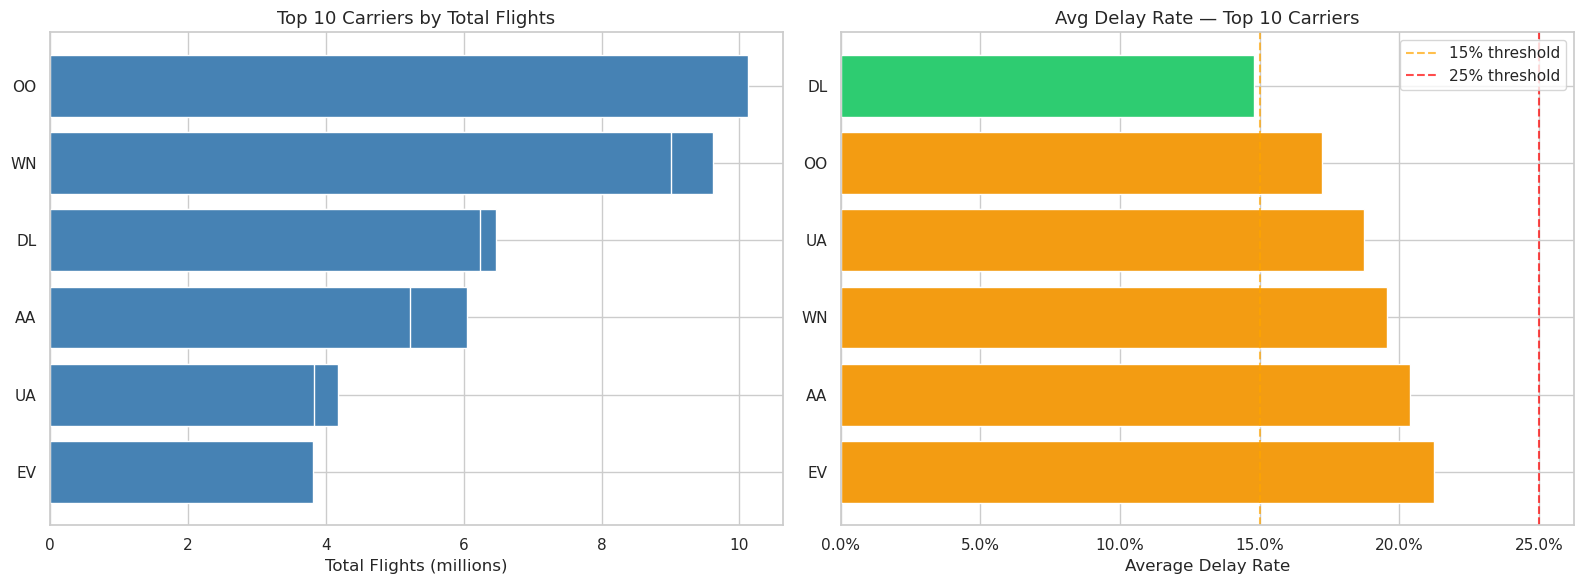


Top 10 carriers by delay rate:
carrier                              carrier_name  delay_rate  total_flights
     KS                    Peninsula Airways Inc.    0.314534         3227.0
     F9                         Frontier Airlines    0.262179      1041066.0
     AX                     Trans States Airlines    0.246016       178098.0
     B6                           JetBlue Airways    0.244888      3741501.0
     C5 Commutair Aka Champlain Enterprises, Inc.    0.243149       280544.0
     G4                             Allegiant Air    0.237488       774867.0
     NK                          Spirit Air Lines    0.236331       412396.0
     OH                               Comair Inc.    0.228533       147633.0
     F9                    Frontier Airlines Inc.    0.225015       696776.0
     NK                           Spirit Airlines    0.214340      1482404.0


In [14]:
carrier_stats = df.groupby(['carrier', 'carrier_name']).agg(
    total_flights=('arr_flights', 'sum'),
    total_delayed=('arr_del15', 'sum'),
    total_cancelled=('arr_cancelled', 'sum')
).reset_index()
carrier_stats['delay_rate'] = carrier_stats['total_delayed'] / carrier_stats['total_flights']
carrier_stats['cancel_rate'] = carrier_stats['total_cancelled'] / carrier_stats['total_flights']
carrier_stats = carrier_stats.sort_values('total_flights', ascending=False)

top10 = carrier_stats.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total flights by carrier
axes[0].barh(top10['carrier'], top10['total_flights']/1e6, color='steelblue')
axes[0].set_title('Top 10 Carriers by Total Flights', fontsize=13)
axes[0].set_xlabel('Total Flights (millions)')
axes[0].invert_yaxis()

# Delay rate by carrier
top10_sorted = top10.sort_values('delay_rate', ascending=True)
colors = ['#e74c3c' if r > 0.25 else '#f39c12' if r > 0.15 else '#2ecc71'
          for r in top10_sorted['delay_rate']]
axes[1].barh(top10_sorted['carrier'], top10_sorted['delay_rate'], color=colors)
axes[1].axvline(0.15, color='orange', linestyle='--', alpha=0.7, label='15% threshold')
axes[1].axvline(0.25, color='red', linestyle='--', alpha=0.7, label='25% threshold')
axes[1].set_title('Avg Delay Rate — Top 10 Carriers', fontsize=13)
axes[1].set_xlabel('Average Delay Rate')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('carrier_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nTop 10 carriers by delay rate:')
print(carrier_stats.nlargest(10, 'delay_rate')[['carrier','carrier_name','delay_rate','total_flights']].to_string(index=False))

## 7. Airport Analysis

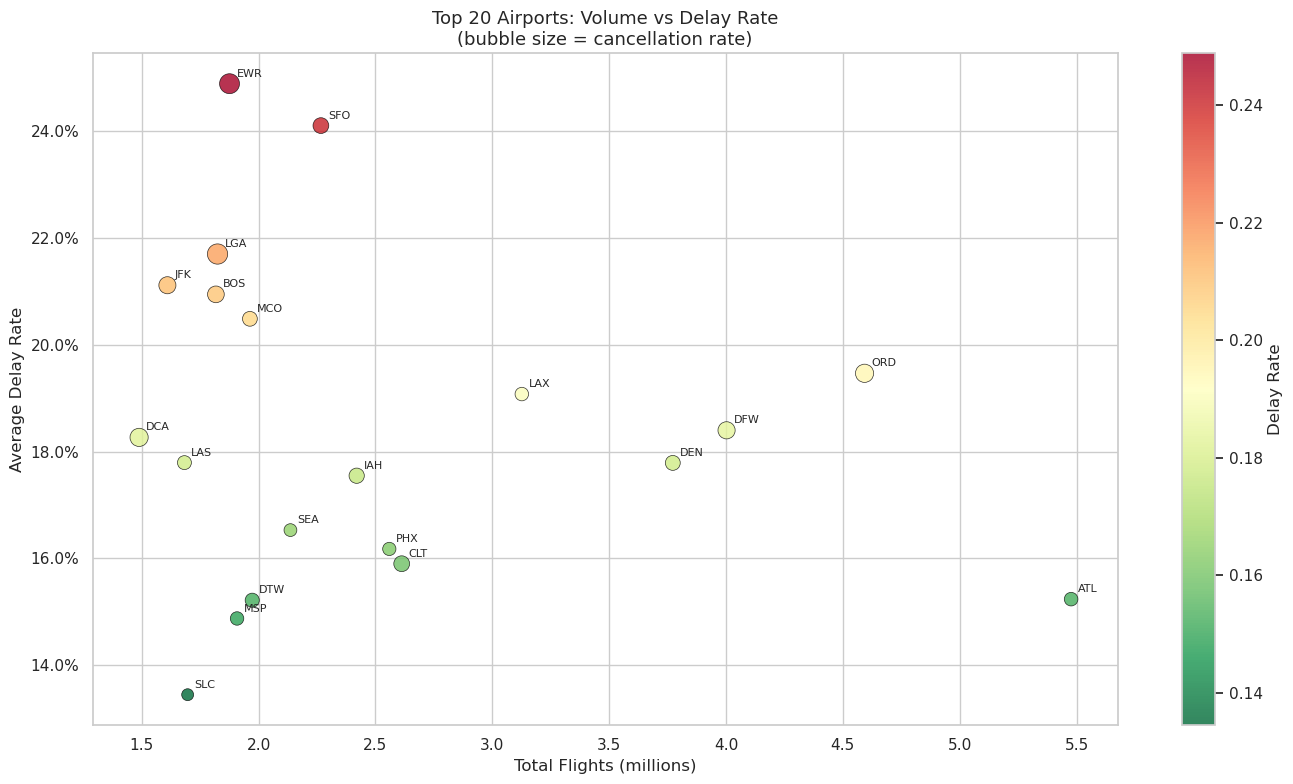

Worst delay rate airports (min 10k flights):
airport  delay_rate  cancel_rate
    BQN    0.292714     0.021253
    PSE    0.289568     0.024967
    PGD    0.279965     0.029792
    SFB    0.269844     0.037337
    TTN    0.258290     0.027014
    AZA    0.251443     0.025299
    EWR    0.248856     0.035146
    ASE    0.242999     0.053306
    SFO    0.241012     0.019795
    PIE    0.237303     0.031504


In [15]:
airport_stats = df.groupby(['airport', 'airport_name']).agg(
    total_flights=('arr_flights', 'sum'),
    total_delayed=('arr_del15', 'sum'),
    total_cancelled=('arr_cancelled', 'sum')
).reset_index()
airport_stats['delay_rate'] = airport_stats['total_delayed'] / airport_stats['total_flights']
airport_stats['cancel_rate'] = airport_stats['total_cancelled'] / airport_stats['total_flights']

# Top 20 by volume
top20_airports = airport_stats.nlargest(20, 'total_flights')

fig, ax = plt.subplots(figsize=(14, 8))
sc = ax.scatter(top20_airports['total_flights']/1e6, top20_airports['delay_rate'],
                s=top20_airports['cancel_rate']*5000+30,
                c=top20_airports['delay_rate'], cmap='RdYlGn_r',
                alpha=0.8, edgecolors='black', linewidth=0.5)
for _, row in top20_airports.iterrows():
    ax.annotate(row['airport'], (row['total_flights']/1e6, row['delay_rate']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Total Flights (millions)', fontsize=12)
ax.set_ylabel('Average Delay Rate', fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_title('Top 20 Airports: Volume vs Delay Rate\n(bubble size = cancellation rate)', fontsize=13)
plt.colorbar(sc, ax=ax, label='Delay Rate')
plt.tight_layout()
plt.savefig('airport_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print('Worst delay rate airports (min 10k flights):')
busy = airport_stats[airport_stats['total_flights'] > 10000]
print(busy.nlargest(10, 'delay_rate')[['airport','delay_rate','cancel_rate']].to_string(index=False))

## 8. Delay Cause Breakdown

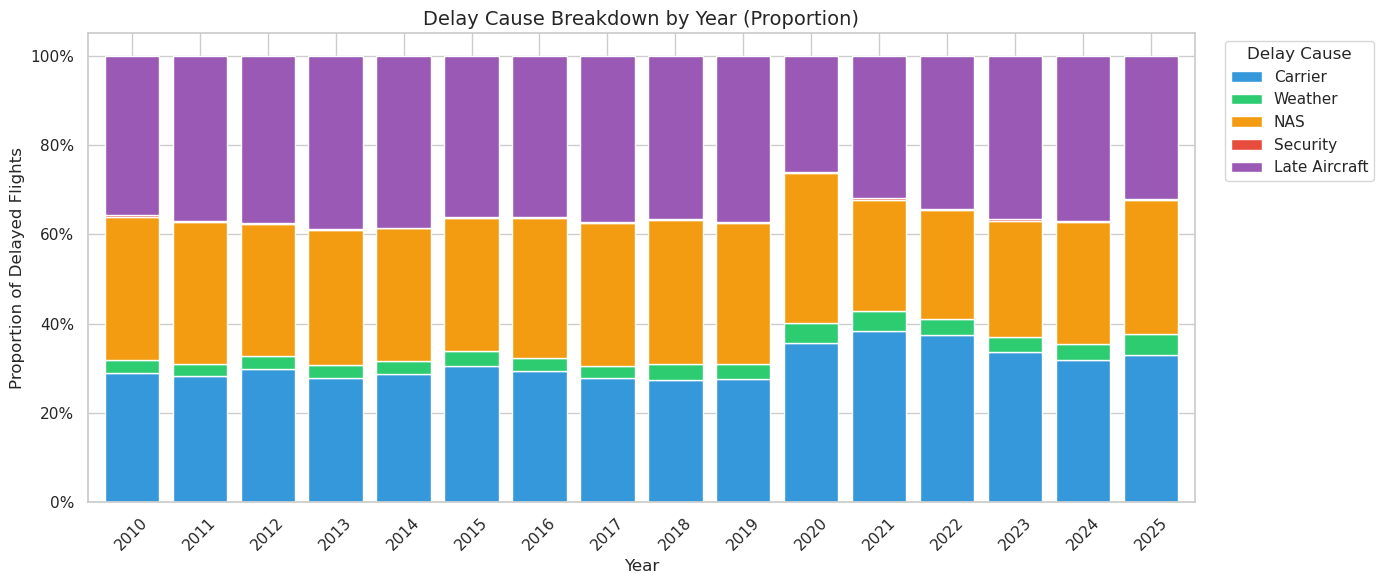


Overall delay cause proportions:
  Carrier: 30.7%
  Weather: 3.3%
  NAS: 29.5%
  Security: 0.2%
  Late Aircraft: 36.2%


In [16]:
cause_cols = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
cause_labels = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']

yearly_causes = df.groupby('year')[cause_cols].sum()
yearly_causes_pct = yearly_causes.div(yearly_causes.sum(axis=1), axis=0)
yearly_causes_pct.columns = cause_labels

fig, ax = plt.subplots(figsize=(14, 6))
yearly_causes_pct.plot(kind='bar', stacked=True, ax=ax,
                        color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'],
                        width=0.8)
ax.set_title('Delay Cause Breakdown by Year (Proportion)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of Delayed Flights')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(title='Delay Cause', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('delay_causes.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nOverall delay cause proportions:')
total_causes = df[cause_cols].sum()
total_causes.index = cause_labels
for cause, val in (total_causes / total_causes.sum()).items():
    print(f'  {cause}: {val*100:.1f}%')

## 9. Correlation Analysis

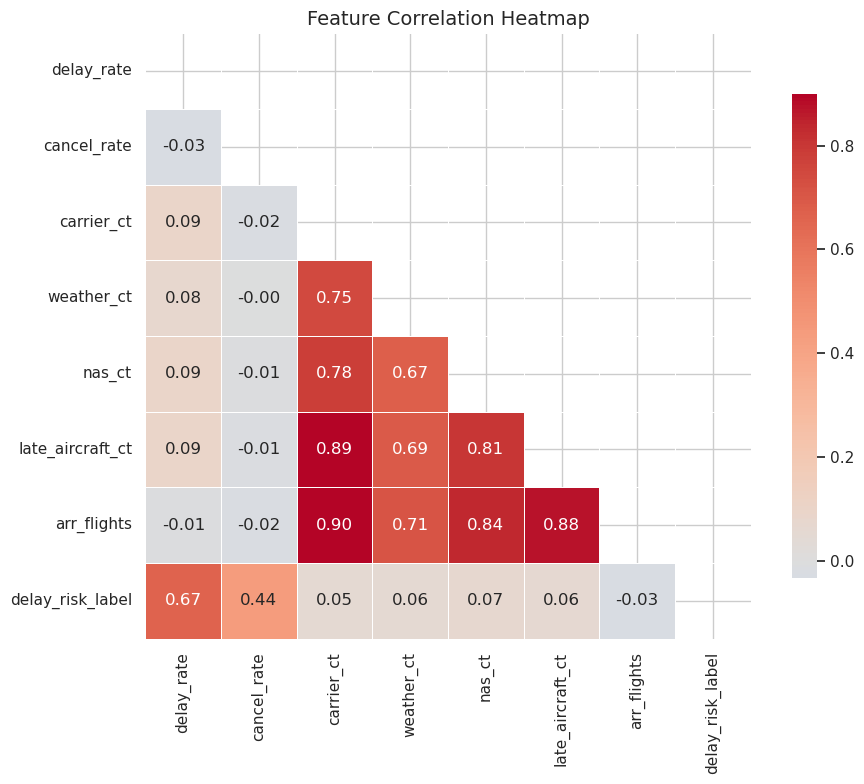

Correlation with delay_risk_label:
delay_risk_label    1.000000
delay_rate          0.665672
cancel_rate         0.443215
nas_ct              0.067013
late_aircraft_ct    0.060420
weather_ct          0.058565
carrier_ct          0.052993
arr_flights        -0.032377


In [17]:
numeric_cols = ['delay_rate', 'cancel_rate', 'carrier_ct', 'weather_ct', 'nas_ct',
                'late_aircraft_ct', 'arr_flights', 'delay_risk_label']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print('Correlation with delay_risk_label:')
print(corr['delay_risk_label'].sort_values(ascending=False).to_string())

## 10. EDA Summary

### Key Findings

| Finding | Detail |
|---|---|
| **Dataset size** | 281,032 records (carrier-airport-month combinations, 2010–2025) filtered from 398,233 raw records; 38 carriers, 425 airports |
| **Class distribution** | Class 0 (on-time): 36.5% · Class 1 (minor-risk): 32.9% · Class 2 (major-risk): 16.0% · Class 3 (high-risk): 14.5% |
| **Class imbalance** | High-risk to on-time ratio = 0.398 — relatively balanced for a multi-class problem; no single class dominates |
| **COVID-19 anomaly** | 2020 shows lowest avg delay rate (9.3%) but highest cancellation rate (6.0%); 2022–2024 rebounded to ~20% delay rate |
| **Seasonal peak** | July has the highest delay rate; September has the lowest — summer convective weather drives cascading delays |
| **Dominant delay cause** | Late aircraft (36.2%) is the single largest cause, followed by carrier (30.7%) and NAS (29.5%); weather only 3.3% |
| **Highest-risk carriers** | Regional/budget carriers lead: Peninsula Airways KS (31.4%), Frontier F9 (26.2%), Trans States AX (24.6%), JetBlue B6 (24.5%) |
| **Highest-risk airports** | Puerto Rico airports dominate: BQN Aguadilla (29.3%), PSE Ponce (28.9%); also PGD Punta Gorda FL (28.0%) |
| **Strongest feature correlations** | `delay_rate` (0.67) and `cancel_rate` (0.44) are far more predictive than individual delay cause counts (all < 0.07) |
| **Volume is slightly protective** | `arr_flights` has a weak negative correlation (−0.03) — larger, busier routes tend to be slightly better managed |

### Further steps:

- **Class weighting / SMOTE**: Despite the relatively balanced ratio (0.398), Class 3 (high-risk) is still under-represented at 14.5% — apply `scale_pos_weight` or SMOTE in NB04 training
- **COVID indicator feature**: Flag 2020–2021 records or add a binary `is_covid_period` feature in NB02 — the inverse delay/cancel pattern in these years will distort learned patterns
- **Rolling lag features**: Engineer per-carrier and per-airport rolling delay rate (3-month, 12-month windows) in NB02 to capture temporal autocorrelation
- **Temporal train/test split**: Use year-based split (train 2010–2018, val 2019–2021, test 2022–2025) in NB03 to prevent data leakage — do NOT random-split time-series data
- **Late aircraft cascade feature**: Engineer `late_aircraft_rate` (late_aircraft_ct / arr_flights) as a first-class input — at 36.2% of all delays, it is the dominant propagation mechanism
- **Consolidate redundant count features**: Individual delay cause counts (carrier_ct, nas_ct, etc.) each correlate < 0.07 with the target; derive rate-based features instead of using raw counts

In [18]:
# --- COVID period flag ---
# 2020: avg delay_rate=0.093 (lowest ever) but cancel_rate=0.060 (highest ever)
# This inverted pattern is anomalous and will confuse a model trained without context
df['is_covid_period'] = df['year'].isin([2020, 2021]).astype(int)
covid_count = df['is_covid_period'].sum()
print(f"COVID-period records flagged: {covid_count:,} ({covid_count/len(df)*100:.1f}% of dataset)")

# --- Late aircraft rate (dominant cause at 36.2%) ---
# Per-flight rate normalises for route volume; NB02 rolling lags will build on this
df['late_aircraft_rate'] = df['late_aircraft_ct'] / df['arr_flights']

# --- Rate-based cause features (replace raw counts) ---
# Raw counts each correlate < 0.07 with target; rates decouple from flight volume
df['carrier_delay_rate'] = df['carrier_ct'] / df['arr_flights']
df['weather_delay_rate'] = df['weather_ct'] / df['arr_flights']
df['nas_delay_rate']     = df['nas_ct']     / df['arr_flights']

# --- Cyclical month encoding ---
# Captures smooth seasonal wrap-around: July (peak) and September (trough) confirmed by EDA
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

new_features = ['is_covid_period', 'late_aircraft_rate',
                'carrier_delay_rate', 'weather_delay_rate', 'nas_delay_rate',
                'month_sin', 'month_cos']
print(f"\nNew features: {new_features}")
print(f"\nDataset shape after feature engineering: {df.shape}")
print(df[new_features].describe().round(4))

COVID-period records flagged: 44,498 (15.8% of dataset)

New features: ['is_covid_period', 'late_aircraft_rate', 'carrier_delay_rate', 'weather_delay_rate', 'nas_delay_rate', 'month_sin', 'month_cos']

Dataset shape after feature engineering: (281032, 32)
       is_covid_period  late_aircraft_rate  carrier_delay_rate  \
count      281032.0000         281032.0000         281032.0000   
mean            0.1583              0.0600              0.0677   
std             0.3651              0.0560              0.0592   
min             0.0000              0.0000              0.0000   
25%             0.0000              0.0215              0.0340   
50%             0.0000              0.0500              0.0582   
75%             0.0000              0.0851              0.0889   
max             1.0000              1.0000              1.0000   

       weather_delay_rate  nas_delay_rate    month_sin    month_cos  
count         281032.0000     281032.0000  281032.0000  281032.0000  
mean     

Correlation of new features with delay_risk_label:
late_aircraft_rate    0.4697
carrier_delay_rate    0.4054
nas_delay_rate        0.3962
weather_delay_rate    0.1833
month_sin             0.1224
month_cos            -0.0594
is_covid_period      -0.0599
Name: delay_risk_label, dtype: float64


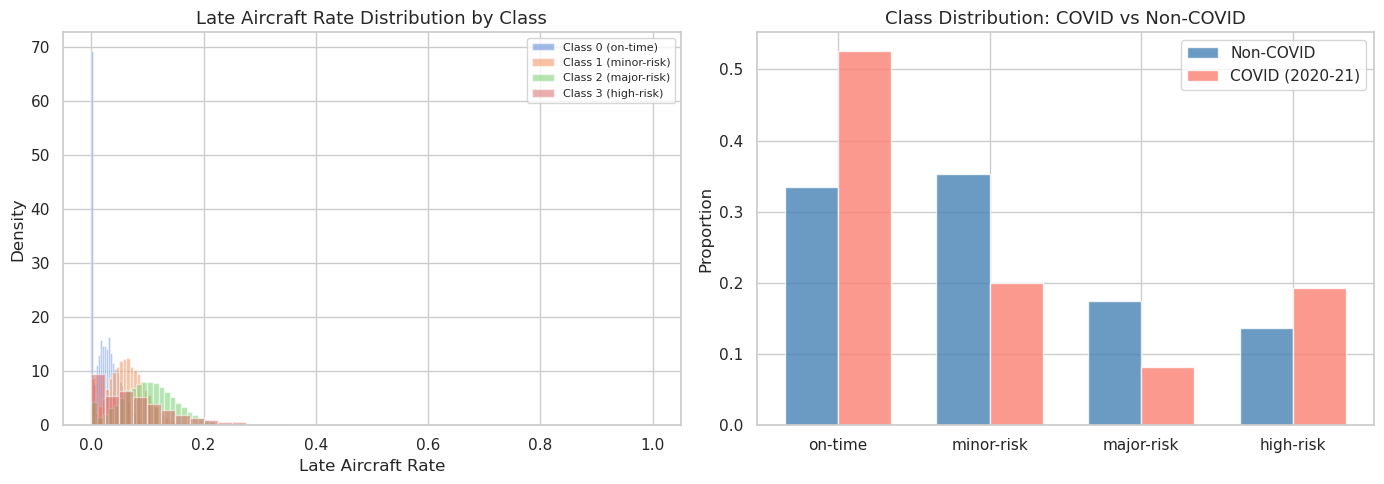

In [19]:
# Correlation of new features with target — confirm they add signal
check_cols = ['late_aircraft_rate', 'carrier_delay_rate', 'weather_delay_rate',
              'nas_delay_rate', 'is_covid_period', 'month_sin', 'month_cos']
new_corr = df[check_cols + ['delay_risk_label']].corr()['delay_risk_label'].drop('delay_risk_label')
print("Correlation of new features with delay_risk_label:")
print(new_corr.sort_values(ascending=False).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# late_aircraft_rate distribution by class
for label in range(4):
    label_map = {0:'on-time', 1:'minor-risk', 2:'major-risk', 3:'high-risk'}
    subset = df[df['delay_risk_label'] == label]['late_aircraft_rate']
    axes[0].hist(subset, bins=40, alpha=0.5, label=f'Class {label} ({label_map[label]})', density=True)
axes[0].set_title('Late Aircraft Rate Distribution by Class', fontsize=13)
axes[0].set_xlabel('Late Aircraft Rate')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# COVID vs non-COVID class distribution
covid_dist    = df[df['is_covid_period'] == 1]['delay_risk_label'].value_counts(normalize=True).sort_index()
noncovid_dist = df[df['is_covid_period'] == 0]['delay_risk_label'].value_counts(normalize=True).sort_index()
x = np.arange(4)
w = 0.35
axes[1].bar(x - w/2, noncovid_dist.values, w, label='Non-COVID', color='steelblue', alpha=0.8)
axes[1].bar(x + w/2, covid_dist.values,    w, label='COVID (2020-21)', color='salmon', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['on-time', 'minor-risk', 'major-risk', 'high-risk'])
axes[1].set_title('Class Distribution: COVID vs Non-COVID', fontsize=13)
axes[1].set_ylabel('Proportion')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_new_features.png', dpi=100, bbox_inches='tight')
plt.show()

## 12. Save Prepared Dataset

Save the enriched dataset (with EDA-derived features) to S3 as `interim/airline_delay_prepared.csv`.
NB02 will load this file directly rather than re-deriving from raw CSV.

In [20]:
# Save prepared dataframe (with all EDA-derived features) for downstream notebooks
LOCAL_PATH = '/tmp/airline_delay_prepared.csv'
S3_KEY     = 'interim/airline_delay_prepared.csv'

df.to_csv(LOCAL_PATH, index=False)
print(f'Saved locally: {LOCAL_PATH}  ({df.shape[0]:,} rows × {df.shape[1]} cols)')

try:
    s3_client.upload_file(LOCAL_PATH, PROCESSED_BUCKET, S3_KEY)
    print(f'Uploaded to s3://{PROCESSED_BUCKET}/{S3_KEY}')
except Exception as e:
    print(f'S3 upload note: {e}')

print(f'\nFinal dataset shape: {df.shape}')
print(f'Target distribution:')
label_names = {0: 'on-time', 1: 'minor-risk', 2: 'major-risk', 3: 'high-risk'}
for cls, cnt in df['delay_risk_label'].value_counts().sort_index().items():
    print(f'  Class {cls} ({label_names[cls]}): {cnt:,} ({cnt/len(df)*100:.1f}%)')
print(f'\nAll columns ({df.shape[1]}):')
print(df.columns.tolist())

Saved locally: /tmp/airline_delay_prepared.csv  (281,032 rows × 32 cols)


Uploaded to s3://skyaware-processed-data/interim/airline_delay_prepared.csv

Final dataset shape: (281032, 32)
Target distribution:
  Class 0 (on-time): 102,652 (36.5%)
  Class 1 (minor-risk): 92,556 (32.9%)
  Class 2 (major-risk): 45,005 (16.0%)
  Class 3 (high-risk): 40,819 (14.5%)

All columns (32):
['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'delay_rate', 'cancel_rate', 'delay_risk_label', 'risk_label_name', 'is_covid_period', 'late_aircraft_rate', 'carrier_delay_rate', 'weather_delay_rate', 'nas_delay_rate', 'month_sin', 'month_cos']
